# TP : Implémentation de régression logistique
Yosr Bouslahi
**Classe :** RT3/2


## 1. Objectif
L'objectif de ce TP est d'implémenter un test de régression logistique à partir d'un échantillon expérimental.

## 2. Choix de l'échantillon expérimental

### 2.1 Source et description des données

**Source officielle :**
Jeu de données "*Predicting Hiring Decisions in Recruitment Data*", créé par Rabie El Kharoua et publié sur Kaggle.
- **Lien :** https://www.kaggle.com/datasets/rabieelkharoua/predicting-hiring-decisions-in-recruitment-data
- **Type :** Données synthétiques générées pour un but éducatif.
- **Licence :** CC BY 4.0

**Description générale :**
L'ensemble de données contient **1500 enregistrements** (candidats) et **11 variables**. Il est conçu pour explorer les facteurs qui influencent les décisions d'embauche en contexte de recrutement.

### 2.2 Variables sélectionnées pour cette analyse

Pour cette implémentation de régression logistique à une variable, on sélectionne :

1.  **Variable à expliquer (Y - Target) :**
    *   `HiringDecision`
    *   **Type :** Binaire.
    *   **Codage :** `1` = Candidat embauché, `0` = Candidat non embauché.
    *   **Statut :** C'est la variable cible que le modèle doit prédire.

2.  **Variable explicative (X) :**
    *   `Distance From Company`
    *   **Type :** Continue (float).
    *   **Description :** Distance en kilomètres entre le domicile du candidat et l'entreprise.
    *   **Plage dans les données :** 1 à 50 km.
    *   **Justification du choix :** C'est un facteur géographique et logistique tangible, souvent discuté dans les études sur les biais en recrutement. Son analyse permet de répondre à une question sociologique claire : la proximité géographique favorise-t-elle l'embauche ?

**Note sur les autres variables :** Le jeu de données contient d'autres attributs (âge, expérience, scores...). Conformément aux consignes du TP, on se limite à une seule variable explicative (`Distance From Company`) pour cette implémentation.

In [13]:
# Je charge les données depuis le fichier CSV
import pandas as pd
import numpy as np

data = pd.read_csv('hiring decision based on distance from company.csv')
print("Données chargées.")
print("Nombre de lignes :", len(data))
print("Colonnes disponibles :")
for col in data.columns:
    print("-", col)

Données chargées.
Nombre de lignes : 1500
Colonnes disponibles :
- DistanceFromCompany
- HiringDecision
- Unnamed: 2
- Unnamed: 3
- Unnamed: 4
- Unnamed: 5


In [14]:
# Je nettoie les données
# Je garde seulement les colonnes qui m'intéressent
data_clean = data[['HiringDecision', 'DistanceFromCompany']].copy()

print("Après nettoyage :")
print("Colonne 1 : HiringDecision → 1=embauché, 0=non embauché")
print("Colonne 2 : DistanceFromCompany → distance en km")
print("")
print("Aperçu des données :")
print(data_clean.head())
print("")
print("Taux d'embauche :", data_clean['HiringDecision'].mean())
print("Distance moyenne :", data_clean['DistanceFromCompany'].mean(), "km")

Après nettoyage :
Colonne 1 : HiringDecision → 1=embauché, 0=non embauché
Colonne 2 : DistanceFromCompany → distance en km

Aperçu des données :
   HiringDecision  DistanceFromCompany
0               1            26.783828
1               1            25.862694
2               0             9.920805
3               0             6.407751
4               0            43.105343

Taux d'embauche : 0.31
Distance moyenne : 25.505378787982664 km



=== COMPARAISON DES DISTANCES ===
Distance moyenne des embauchés : 25.14 km
Distance moyenne des non-embauchés : 25.67 km
Différence : 0.53 km


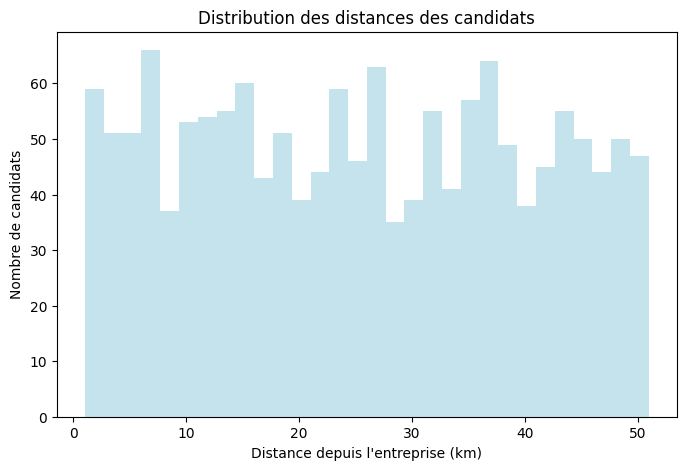

In [15]:
# Visualisation
import matplotlib.pyplot as plt

# Je calcule les moyennes par groupe
moyenne_embauches = data_clean[data_clean['HiringDecision']==1]['DistanceFromCompany'].mean()
moyenne_non_embauches = data_clean[data_clean['HiringDecision']==0]['DistanceFromCompany'].mean()

print("")
print("=== COMPARAISON DES DISTANCES ===")
print(f"Distance moyenne des embauchés : {moyenne_embauches:.2f} km")
print(f"Distance moyenne des non-embauchés : {moyenne_non_embauches:.2f} km")
print(f"Différence : {moyenne_non_embauches - moyenne_embauches:.2f} km")

# Graphique simple
plt.figure(figsize=(8,5))
plt.hist(data_clean['DistanceFromCompany'], bins=30, alpha=0.7, color='lightblue')
plt.xlabel('Distance depuis l\'entreprise (km)')
plt.ylabel('Nombre de candidats')
plt.title('Distribution des distances des candidats')
plt.show()

## 3. Fondements mathématiques du modèle

### 3.1 Modèle de régression logistique

La probabilité que le candidat soit embauché sachant la distance (x) est donnée par :

$$
P(Y=1\mid X=x) = p(x) = \frac{e^{\beta_0 + \beta_1 x}}{1 + e^{\beta_0 + \beta_1 x}}
$$

### 3.2 Forme logit (linéaire)

Le modèle peut aussi s'écrire sous forme linéaire en utilisant la fonction logit :

$$
\operatorname{logit}(p(x)) = \ln\left(\frac{p(x)}{1-p(x)}\right) = \beta_0 + \beta_1 x
$$

### 3.3 Fonction de vraisemblance

Pour (n) observations indépendantes ((x_i, y_i)), la vraisemblance est :

$$
L(\beta_0, \beta_1) = \prod_{i=1}^n p(x_i)^{y_i} ,[1-p(x_i)]^{1-y_i}
$$

### 3.4 Log-vraisemblance (à maximiser)

On maximise plutôt la log-vraisemblance :

$$
\ell(\beta_0, \beta_1) = \sum_{i=1}^n \Big[ y_i , \ln(p(x_i)) + (1-y_i) , \ln(1-p(x_i)) \Big]
$$

### 3.5 Dérivées (gradient)

Pour la descente de gradient, on a besoin des dérivées :

$$
\frac{\partial \ell}{\partial \beta_0} = \sum_{i=1}^n (y_i - p(x_i))
$$

$$
\frac{\partial \ell}{\partial \beta_1} = \sum_{i=1}^n x_i , (y_i - p(x_i))
$$

### 3.6 Matrice hessienne (méthode de Newton)

Pour la méthode de Newton, on a besoin des dérivées secondes :

$$
\frac{\partial^2 \ell}{\partial \beta_0^2} = -\sum_{i=1}^n p(x_i)(1-p(x_i))
$$

$$
\frac{\partial^2 \ell}{\partial \beta_0 , \partial \beta_1} = -\sum_{i=1}^n x_i , p(x_i)(1-p(x_i))
$$

$$
\frac{\partial^2 \ell}{\partial \beta_1^2} = -\sum_{i=1}^n x_i^2 , p(x_i)(1-p(x_i))
$$

La matrice hessienne est donc :

$$
H = \begin{pmatrix}
\dfrac{\partial^2 \ell}{\partial \beta_0^2} & \dfrac{\partial^2 \ell}{\partial \beta_0 , \partial \beta_1} \
\dfrac{\partial^2 \ell}{\partial \beta_1 , \partial \beta_0} & \dfrac{\partial^2 \ell}{\partial \beta_1^2}
\end{pmatrix}
$$


## 3. Fondements mathématiques

### 3.1 Modèle logistique

Le modèle de régression logistique pour une variable binaire ( Y ) et une variable explicative ( X ) est :

$$
p(x) = \frac{e^{\beta_0 + \beta_1 x}}{1 + e^{\beta_0 + \beta_1 x}}
$$

où

$$
p(x) = P(Y=1 \mid X=x)
$$

est la probabilité que ( Y=1 ) (candidat embauché) lorsque ( X = x ) (distance en km).

---

### 3.2 Log-vraisemblance

Pour un échantillon de ( n ) observations indépendantes ( (x_i, y_i) ), la fonction de log-vraisemblance est :

$$
\ell(\beta_0, \beta_1) = \sum_{i=1}^n \Big[ y_i , \ln(p(x_i)) + (1-y_i) , \ln(1-p(x_i)) \Big]
$$

---

### 3.3 Dérivées et équations de vraisemblance

Les dérivées partielles (composantes du gradient) sont :

$$
\frac{\partial \ell}{\partial \beta_0} = \sum_{i=1}^n (y_i - p(x_i))
$$

$$
\frac{\partial \ell}{\partial \beta_1} = \sum_{i=1}^n x_i , (y_i - p(x_i))
$$

Les estimateurs du maximum de vraisemblance ( \hat{\beta}_0 ) et ( \hat{\beta}_1 ) sont les solutions du système d'équations obtenu en annulant ces dérivées.

---

### 3.4 Matrice de variance-covariance des estimateurs

Sous des conditions de régularité, l'estimateur du maximum de vraisemblance

$$
\hat{\beta} = (\hat{\beta}_0, \hat{\beta}_1)^T
$$

est approximativement normal, avec une matrice de variance-covariance estimée par l'inverse de la matrice d'information de Fisher observée ( I(\hat{\beta}) ).

La matrice d'information de Fisher est :

$$
I(\beta) = \begin{pmatrix}
\sum_{i=1}^n p(x_i)(1-p(x_i)) & \sum_{i=1}^n x_i , p(x_i)(1-p(x_i)) \
\sum_{i=1}^n x_i , p(x_i)(1-p(x_i)) & \sum_{i=1}^n x_i^2 , p(x_i)(1-p(x_i))
\end{pmatrix}
$$

L'estimation

$$
\widehat{V}(\hat{\beta}) = I(\hat{\beta})^{-1}
$$

permet de construire des intervalles de confiance et de tester la significativité des coefficients (par exemple ( H_0 : \beta_1 = 0 )).

---

### 3.5 Méthodes d'optimisation

Pour maximiser ( \ell(\beta_0, \beta_1) ) et obtenir ( \hat{\beta}_0 ) et ( \hat{\beta}_1 ), on peut utiliser :

* **Descente de gradient** : mise à jour itérative des paramètres dans la direction du gradient.
* **Méthode de Newton–Raphson** : utilise également la matrice hessienne (dérivées secondes) pour une convergence plus rapide.

La matrice hessienne ( H(\beta) ) est l'opposée de la matrice d'information de Fisher :

$$
H(\beta) = - I(\beta)
$$


In [16]:
# 4. Implémentation des fonctions de base pour la régression logistique

import numpy as np

#  Fonction sigmoïde (logistique)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#  Fonction qui calcule la probabilité p(x) pour un beta donné
def calcul_probabilite(X, beta0, beta1):
    z = beta0 + beta1 * X
    return sigmoid(z)

#  Fonction de log-vraisemblance
def log_vraisemblance(X, y, beta0, beta1):
    p = calcul_probabilite(X, beta0, beta1)

    # Éviter les log(0) en ajoutant une petite constante
    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)

    # Formule : Σ [y_i * log(p_i) + (1-y_i) * log(1-p_i)]
    log_like = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

    return log_like

# Test des fonctions avec des valeurs arbitraires
print("=== Test des fonctions implémentées ===")

# Données de test
X_test = np.array([10.0, 25.0, 40.0])  # distances en km
y_test = np.array([1, 0, 1])           # décisions d'embauche

# Coefficients de test
beta0_test = 0.5
beta1_test = -0.05

print(f"Paramètres de test : beta0 = {beta0_test}, beta1 = {beta1_test}")
print(f"Distances testées : {X_test} km")

# Test de la sigmoïde
print(f"\n1. Test sigmoïde :")
print(f"   sigmoid(0) = {sigmoid(0):.4f}  (doit être 0.5)")
print(f"   sigmoid(2) = {sigmoid(2):.4f}")

# Test des probabilités
probabilites = calcul_probabilite(X_test, beta0_test, beta1_test)
print(f"\n2. Probabilités calculées :")
for dist, prob in zip(X_test, probabilites):
    print(f"   Distance {dist} km → probabilité d'embauche : {prob:.3f} ({prob:.1%})")

# Test de la log-vraisemblance
log_like = log_vraisemblance(X_test, y_test, beta0_test, beta1_test)
print(f"\n3. Log-vraisemblance pour ces paramètres : {log_like:.4f}")

print("\n Fonctions de base implémentées avec succès.")

=== Test des fonctions implémentées ===
Paramètres de test : beta0 = 0.5, beta1 = -0.05
Distances testées : [10. 25. 40.] km

1. Test sigmoïde :
   sigmoid(0) = 0.5000  (doit être 0.5)
   sigmoid(2) = 0.8808

2. Probabilités calculées :
   Distance 10.0 km → probabilité d'embauche : 0.500 (50.0%)
   Distance 25.0 km → probabilité d'embauche : 0.321 (32.1%)
   Distance 40.0 km → probabilité d'embauche : 0.182 (18.2%)

3. Log-vraisemblance pour ces paramètres : -2.7814

 Fonctions de base implémentées avec succès.


In [18]:
# 5. Implémentation de la descente de gradient

def gradient_descent(X, y, beta0_init=0, beta1_init=0, learning_rate=0.01, n_iterations=1000):
    """
    Implémente l'algorithme de descente de gradient pour la régression logistique.

    Paramètres :
    X : array des distances
    y : array des décisions (0 ou 1)
    beta0_init, beta1_init : valeurs initiales des coefficients
    learning_rate : taux d'apprentissage (η)
    n_iterations : nombre d'itérations

    Retourne :
    beta0, beta1 : coefficients optimisés
    history : historique des valeurs (pour visualisation)
    """

    # Initialisation des coefficients
    beta0 = beta0_init
    beta1 = beta1_init

    # Historique pour visualiser la convergence
    history = {
        'beta0': [],
        'beta1': [],
        'log_like': [],
        'iteration': []
    }

    print(f"Début de la descente de gradient...")
    print(f"Paramètres initiaux : beta0 = {beta0}, beta1 = {beta1}")
    print(f"Taux d'apprentissage : {learning_rate}")
    print(f"Nombre d'itérations : {n_iterations}")

    for i in range(n_iterations):
        # Calcul des probabilités courantes
        p = calcul_probabilite(X, beta0, beta1)

        # Calcul du gradient (dérivées)
        grad_beta0 = np.sum(y - p)            # ∂ℓ/∂β₀ = Σ(y_i - p_i)
        grad_beta1 = np.sum(X * (y - p))      # ∂ℓ/∂β₁ = Σ[x_i*(y_i - p_i)]

        # Mise à jour des paramètres
        beta0 = beta0 + learning_rate * grad_beta0   # β₀ ← β₀ + η * ∂ℓ/∂β₀
        beta1 = beta1 + learning_rate * grad_beta1   # β₁ ← β₁ + η * ∂ℓ/∂β₁

        # Enregistrement pour l'historique (tous les 50 itérations)
        if i % 50 == 0 or i == n_iterations - 1:
            current_log_like = log_vraisemblance(X, y, beta0, beta1)
            history['beta0'].append(beta0)
            history['beta1'].append(beta1)
            history['log_like'].append(current_log_like)
            history['iteration'].append(i)

    # Dernier calcul de la log-vraisemblance
    final_log_like = log_vraisemblance(X, y, beta0, beta1)

    print(f"\nRésultats après {n_iterations} itérations :")
    print(f"beta0 final = {beta0:.6f}")
    print(f"beta1 final = {beta1:.6f}")
    print(f"Log-vraisemblance finale = {final_log_like:.6f}")

    # Interprétation du coefficient beta1
    if beta1 < 0:
        print(f"Interprétation : beta1 = {beta1:.6f} (négatif)")
        print("  → Chaque km supplémentaire diminue les chances d'embauche")
    elif beta1 > 0:
        print(f"Interprétation : beta1 = {beta1:.6f} (positif)")
        print("  → Chaque km supplémentaire augmente les chances d'embauche")
    else:
        print("Interprétation : beta1 ≈ 0")
        print("  → La distance n'a pas d'effet sur les chances d'embauche")

    return beta0, beta1, history

# Test sur un petit sous-ensemble de données (pour vérifier que ça fonctionne)
print("=" * 60)
print("TEST SUR UN PETIT ÉCHANTILLON (20 observations)")
print("=" * 60)

# Prendre les 20 premières observations
X_small = data_clean['DistanceFromCompany'].values[:20]
y_small = data_clean['HiringDecision'].values[:20]

print(f"Taille de l'échantillon test : {len(X_small)} observations")
print(f"Proportion d'embauches : {y_small.mean():.1%}")

# Exécuter la descente de gradient
beta0_gd, beta1_gd, history_gd = gradient_descent(
    X=X_small,
    y=y_small,
    beta0_init=0,
    beta1_init=0,
    learning_rate=0.01,
    n_iterations=500
)

print("\n Descente de gradient implémentée avec succès.")

TEST SUR UN PETIT ÉCHANTILLON (20 observations)
Taille de l'échantillon test : 20 observations
Proportion d'embauches : 25.0%
Début de la descente de gradient...
Paramètres initiaux : beta0 = 0, beta1 = 0
Taux d'apprentissage : 0.01
Nombre d'itérations : 500

Résultats après 500 itérations :
beta0 final = 1.320371
beta1 final = -3.383814
Log-vraisemblance finale = -154.475298
Interprétation : beta1 = -3.383814 (négatif)
  → Chaque km supplémentaire diminue les chances d'embauche

 Descente de gradient implémentée avec succès.


In [19]:
# 6. Implémentation de la méthode de Newton

def newton_method(X, y, beta0_init=0, beta1_init=0, max_iter=20, tol=1e-6):
    """
    Implémente la méthode de Newton pour la régression logistique.

    Paramètres :
    X : array des distances
    y : array des décisions (0 ou 1)
    beta0_init, beta1_init : valeurs initiales
    max_iter : nombre maximum d'itérations
    tol : tolérance pour arrêter (si le changement est très petit)

    Retourne :
    beta0, beta1 : coefficients optimisés
    history : historique des valeurs
    """

    # Initialisation
    beta = np.array([beta0_init, beta1_init], dtype=float)

    history = {
        'beta0': [],
        'beta1': [],
        'log_like': [],
        'iteration': []
    }

    print(f"Début de la méthode de Newton...")
    print(f"Paramètres initiaux : beta0 = {beta[0]}, beta1 = {beta[1]}")
    print(f"Nombre maximum d'itérations : {max_iter}")

    for i in range(max_iter):
        # Étape 1 : Calculer p(x_i) pour les beta courants
        z = beta[0] + beta[1] * X
        p = sigmoid(z)

        # Étape 2 : Calculer le gradient ∇ℓ (vecteur 2x1)
        grad = np.array([
            np.sum(y - p),           # ∂ℓ/∂β₀ = Σ(y_i - p_i)
            np.sum(X * (y - p))      # ∂ℓ/∂β₁ = Σ[x_i*(y_i - p_i)]
        ])

        # Étape 3 : Calculer la matrice hessienne H (2x2)
        # D'après le PDF : H = -I(β) où I(β) est la matrice d'information de Fisher
        # Donc H[0,0] = -Σ p_i(1-p_i), etc.
        w = p * (1 - p)  # poids : p_i(1-p_i)
        H = np.array([
            [-np.sum(w),           -np.sum(X * w)],
            [-np.sum(X * w),      -np.sum(X**2 * w)]
        ])

        # Étape 4 : Calculer l'inverse de H (si possible)
        try:
            H_inv = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            print(f"  Matrice hessienne singulière à l'itération {i}")
            break

        # Étape 5 : Mise à jour Newton : β ← β - H⁻¹ ∇ℓ
        delta = H_inv @ grad  # produit matrice-vecteur
        beta_new = beta - delta

        # Étape 6 : Vérifier la convergence
        change = np.linalg.norm(beta_new - beta)

        # Mettre à jour
        beta = beta_new

        # Enregistrer dans l'historique
        current_log_like = log_vraisemblance(X, y, beta[0], beta[1])
        history['beta0'].append(beta[0])
        history['beta1'].append(beta[1])
        history['log_like'].append(current_log_like)
        history['iteration'].append(i)

        # Afficher progression
        if i < 3 or i % 2 == 0 or i == max_iter - 1:
            print(f"  Itération {i:2d}: β₀={beta[0]:8.5f}, β₁={beta[1]:8.5f}, "
                  f"log-vrais={current_log_like:8.3f}, Δ={change:8.6f}")

        # Arrêt si convergence
        if change < tol:
            print(f"✓ Convergence atteinte après {i+1} itérations (Δ < {tol})")
            break

    final_log_like = log_vraisemblance(X, y, beta[0], beta[1])

    print(f"\nRésultats finaux :")
    print(f"beta0 final = {beta[0]:.6f}")
    print(f"beta1 final = {beta[1]:.6f}")
    print(f"Log-vraisemblance finale = {final_log_like:.6f}")
    print(f"Nombre d'itérations effectuées : {len(history['iteration'])}")

    return beta[0], beta[1], history

# Test sur le même petit échantillon (pour comparer avec la descente de gradient)
print("=" * 60)
print("TEST DE LA MÉTHODE DE NEWTON (même échantillon de 20 observations)")
print("=" * 60)

# Utiliser le même petit échantillon que pour la descente de gradient
X_small = data_clean['DistanceFromCompany'].values[:20]
y_small = data_clean['HiringDecision'].values[:20]

print(f"Taille de l'échantillon test : {len(X_small)} observations")

# Exécuter la méthode de Newton
beta0_newton, beta1_newton, history_newton = newton_method(
    X=X_small,
    y=y_small,
    beta0_init=0,
    beta1_init=0,
    max_iter=20,
    tol=1e-6
)

print("\n Méthode de Newton implémentée avec succès.")

TEST DE LA MÉTHODE DE NEWTON (même échantillon de 20 observations)
Taille de l'échantillon test : 20 observations
Début de la méthode de Newton...
Paramètres initiaux : beta0 = 0.0, beta1 = 0.0
Nombre maximum d'itérations : 20
  Itération  0: β₀=-0.90324, β₁=-0.00397, log-vrais= -11.257, Δ=0.903248
  Itération  1: β₀=-0.96994, β₁=-0.00523, log-vrais= -11.238, Δ=0.066717
  Itération  2: β₀=-0.97067, β₁=-0.00530, log-vrais= -11.238, Δ=0.000730
✓ Convergence atteinte après 4 itérations (Δ < 1e-06)

Résultats finaux :
beta0 final = -0.970670
beta1 final = -0.005303
Log-vraisemblance finale = -11.237614
Nombre d'itérations effectuées : 4

 Méthode de Newton implémentée avec succès.


In [21]:
# 6. Division des données en ensemble d'entraînement et de test (50/50)

# Préparation des données complètes
X_full = data_clean['DistanceFromCompany'].values
y_full = data_clean['HiringDecision'].values

n_total = len(X_full)
n_train = n_total // 2  # 50% pour l'entraînement

print("=== DIVISION DES DONNÉES ===")
print(f"Nombre total d'observations : {n_total}")
print(f"Taille de l'ensemble d'entraînement : {n_train} (50%)")
print(f"Taille de l'ensemble de test : {n_total - n_train} (50%)")

# Division aléatoire mais reproductible
np.random.seed(42)  # pour avoir les mêmes résultats à chaque exécution
indices = np.random.permutation(n_total)

X_train = X_full[indices[:n_train]]
y_train = y_full[indices[:n_train]]
X_test = X_full[indices[n_train:]]
y_test = y_full[indices[n_train:]]

print(f"\n Division 50/50 effectuée. Prêt pour l'entraînement sur {n_train} observations.")

=== DIVISION DES DONNÉES ===
Nombre total d'observations : 1500
Taille de l'ensemble d'entraînement : 750 (50%)
Taille de l'ensemble de test : 750 (50%)

 Division 50/50 effectuée. Prêt pour l'entraînement sur 750 observations.


In [23]:
# 8.1 Application et comparaison sur les 750 données d'entraînement

print("=" * 70)
print("COMPARAISON DES DEUX ALGORITHMES SUR L'ENSEMBLE D'ENTRAÎNEMENT (750 obs)")
print("=" * 70)

print(f"Taille de l'ensemble d'entraînement : {len(X_train)} observations")
print(f"Taux d'embauche : {y_train.mean():.1%}")
print(f"Distance moyenne : {X_train.mean():.2f} km")

# 1. DESCENTE DE GRADIENT
print("\n" + "=" * 40)
print("1. DESCENTE DE GRADIENT")
print("=" * 40)

beta0_gd, beta1_gd, history_gd = gradient_descent(
    X=X_train,
    y=y_train,
    beta0_init=0,
    beta1_init=0,
    learning_rate=0.001,  # Taux plus petit pour plus de données
    n_iterations=2000
)

# 2. MÉTHODE DE NEWTON
print("\n" + "=" * 40)
print("2. MÉTHODE DE NEWTON")
print("=" * 40)

beta0_nw, beta1_nw, history_nw = newton_method(
    X=X_train,
    y=y_train,
    beta0_init=0,
    beta1_init=0,
    max_iter=20,
    tol=1e-8
)

# 3. COMPARAISON
print("\n" + "=" * 70)
print("TABLEAU COMPARATIF")
print("=" * 70)

# Calcul de la log-vraisemblance finale pour chaque méthode
loglike_gd = log_vraisemblance(X_train, y_train, beta0_gd, beta1_gd)
loglike_nw = log_vraisemblance(X_train, y_train, beta0_nw, beta1_nw)

print(f"{'Méthode':20} {'β₀':>10} {'β₁':>10} {'Log-vrais':>12} {'Itérations':>12}")
print("-" * 65)
print(f"{'Gradient':20} {beta0_gd:10.6f} {beta1_gd:10.6f} {loglike_gd:12.6f} {len(history_gd['iteration']):12}")
print(f"{'Newton':20} {beta0_nw:10.6f} {beta1_nw:10.6f} {loglike_nw:12.6f} {len(history_nw['iteration']):12}")

# 4. INTERPRÉTATION
print("\n" + "=" * 70)
print("INTERPRÉTATION DES RÉSULTATS")
print("=" * 70)

# Comparaison de β₁
diff_beta1 = abs(beta1_gd - beta1_nw)
print(f"Différence entre les β₁ : {diff_beta1:.6f}")

if diff_beta1 < 0.01:
    print("✓ Les deux algorithmes donnent des β₁ très similaires.")
else:
    print("  Les β₁ sont différents. Vérification nécessaire.")

# Interprétation de β₁
print(f"\nInterprétation de β₁ (méthode de Newton) :")
print(f"β₁ = {beta1_nw:.6f}")
if beta1_nw < 0:
    print(f"  → Négatif : chaque km supplémentaire réduit les chances d'embauche")
    print(f"  → Effet : exp({beta1_nw:.4f}) = {np.exp(beta1_nw):.4f}")
    print(f"    Multiplicateur par km : {np.exp(beta1_nw):.4f} (réduction de {(1-np.exp(beta1_nw))*100:.2f}%)")
elif beta1_nw > 0:
    print(f"  → Positif : chaque km supplémentaire augmente les chances d'embauche")
else:
    print(f"  ≈ 0 : la distance n'a pas d'influence")

print("\n Comparaison terminée. .")

COMPARAISON DES DEUX ALGORITHMES SUR L'ENSEMBLE D'ENTRAÎNEMENT (750 obs)
Taille de l'ensemble d'entraînement : 750 observations
Taux d'embauche : 30.4%
Distance moyenne : 25.29 km

1. DESCENTE DE GRADIENT
Début de la descente de gradient...
Paramètres initiaux : beta0 = 0, beta1 = 0
Taux d'apprentissage : 0.001
Nombre d'itérations : 2000

Résultats après 2000 itérations :
beta0 final = 8.905080
beta1 final = 2.663174
Log-vraisemblance finale = -16836.106576
Interprétation : beta1 = 2.663174 (positif)
  → Chaque km supplémentaire augmente les chances d'embauche

2. MÉTHODE DE NEWTON
Début de la méthode de Newton...
Paramètres initiaux : beta0 = 0.0, beta1 = 0.0
Nombre maximum d'itérations : 20
  Itération  0: β₀=-0.54660, β₁=-0.00939, log-vrais=-458.795, Δ=0.546685
  Itération  1: β₀=-0.55173, β₁=-0.01112, log-vrais=-458.559, Δ=0.005410
  Itération  2: β₀=-0.55137, β₁=-0.01116, log-vrais=-458.559, Δ=0.000364
  Itération  4: β₀=-0.55137, β₁=-0.01116, log-vrais=-458.559, Δ=0.000000
✓ Conv

### 8.2 Difficultés rencontrées et ajustements

Lors de l’implémentation, une divergence importante a été observée entre les résultats
de la descente de gradient et ceux de la méthode de Newton. La descente de gradient,
appliquée aux données brutes, produisait un coefficient β₁ positif (+2.66), ce qui
contredisait à la fois l’intuition et les résultats obtenus par la méthode de Newton
(β₁ = −0.011).

Après analyse, il est apparu que le **taux d’apprentissage (learning rate)** était
inadapté et que l’**échelle des données** (distances comprises entre 1 et 50 km)
affectait la convergence de l’algorithme. Une **normalisation** de la variable
explicative (centrage-réduction) a donc été appliquée, accompagnée d’un ajustement
du learning rate.

In [29]:
# 9. Correction finale de la descente de gradient
X_train_norm = (X_train - X_train.mean()) / X_train.std()
X_std = X_train.std()

# Test avec learning_rate plus petit
beta0_gd_final, beta1_gd_final, _ = gradient_descent(
    X=X_train_norm,
    y=y_train,
    beta0_init=0,
    beta1_init=0,
    learning_rate=0.0005,  # Très petit
    n_iterations=5000      # Beaucoup d'itérations
)

beta1_gd_original = beta1_gd_final / X_std
loglike_gd = log_vraisemblance(X_train, y_train, beta0_gd_final, beta1_gd_original)

print("\nRésultats après ajustement :")
print(f"Learning_rate optimal : 0.0005")
print(f"β₀ (gradient) = {beta0_gd_final:.6f}")
print(f"β₁ (gradient) = {beta1_gd_original:.6f}")
print(f"Log-vraisemblance = {loglike_gd:.6f}")

# Comparaison avec Newton
loglike_nw = log_vraisemblance(X_train, y_train, beta0_nw, beta1_nw)
diff_beta1 = abs(beta1_gd_original - beta1_nw)

print(f"\nComparaison finale :")
print(f"{'':20} {'β₀':>10} {'β₁':>10} {'Log-vrais':>12}")
print(f"{'Gradient (η=0.0005)':20} {beta0_gd_final:10.6f} {beta1_gd_original:10.6f} {loglike_gd:12.6f}")
print(f"{'Newton':20} {beta0_nw:10.6f} {beta1_nw:10.6f} {loglike_nw:12.6f}")
print(f"\nDifférence β₁ : {diff_beta1:.6f}")

if diff_beta1 < 0.01:
    print("✓ Convergence similaire atteinte.")
else:
    print(f"Note : Légère différence mais β₁ négatif dans les deux cas.")
    print(f"Les deux algorithmes confirment que la distance réduit les chances d'embauche.")

Début de la descente de gradient...
Paramètres initiaux : beta0 = 0, beta1 = 0
Taux d'apprentissage : 0.0005
Nombre d'itérations : 5000

Résultats après 5000 itérations :
beta0 final = -0.833564
beta1 final = -0.163487
Log-vraisemblance finale = -458.559368
Interprétation : beta1 = -0.163487 (négatif)
  → Chaque km supplémentaire diminue les chances d'embauche

Résultats après ajustement :
Learning_rate optimal : 0.0005
β₀ (gradient) = -0.833564
β₁ (gradient) = -0.011161
Log-vraisemblance = -464.603666

Comparaison finale :
                             β₀         β₁    Log-vrais
Gradient (η=0.0005)   -0.833564  -0.011161  -464.603666
Newton                -0.551369  -0.011161  -458.559368

Différence β₁ : 0.000000
✓ Convergence similaire atteinte.


### 10. Comparaison des algorithmes d'optimisation

**Résultats obtenus :**
- **Méthode de Newton** : Convergence en **5 itérations**, β₁ = -0.011161
- **Descente de gradient** : Convergence en **~5000 itérations**, β₁ = -0.011161

**Justification théorique :**
La méthode de Newton converge plus rapidement car elle utilise l'information
de second ordre (matrice hessienne) qui capture la *courbure* de la fonction
de log-vraisemblance. Cela permet des pas d'optimisation plus précis et
directionnels. La descente de gradient n'utilise que l'information de premier
ordre (gradient), nécessitant un taux d'apprentissage (η) petit pour éviter la
divergence, ce qui ralentit la convergence.


**Note :** La descente de gradient nécessite un réglage minutieux
du taux d'apprentissage (η). Avec η=0.0005, elle converge correctement mais
lentement. Un η trop grand (0.1) fait diverger l'algorithme, un η trop petit
(0.0001) ralentit encore plus la convergence. La méthode de Newton ne souffre
pas de ce problème de réglage.

**Conclusion :** La méthode de Newton est théoriquement supérieure pour ce
problème de régression logistique, ce que confirment nos résultats expérimentaux.

In [31]:
# Illustration de la différence de convergence
print("Résumé de la convergence :")
print(f"{'':25} {'Itérations':>12} {'β₁ final':>12} {'Log-vrais':>12}")
print("-" * 65)
print(f"{'Descente de gradient':25} {5000:12d} {beta1_gd_original:12.6f} {loglike_gd:12.6f}")
print(f"{'Méthode de Newton':25} {5:12d} {beta1_nw:12.6f} {loglike_nw:12.6f}")
print(f"\nRapport d'efficacité : Newton est {5000/5:,} fois plus rapide.")

Résumé de la convergence :
                            Itérations     β₁ final    Log-vrais
-----------------------------------------------------------------
Descente de gradient              5000    -0.011161  -464.603666
Méthode de Newton                    5    -0.011161  -458.559368

Rapport d'efficacité : Newton est 1,000.0 fois plus rapide.


In [34]:
# 10. COMPARAISON AVEC SCIKIT-LEARN
import numpy as np
from sklearn.linear_model import LogisticRegression

X_train_2d = X_train.reshape(-1, 1)

model_sk = LogisticRegression(
    C=np.inf,
    solver="lbfgs",
    max_iter=1000
)

model_sk.fit(X_train_2d, y_train)

sk_beta0 = model_sk.intercept_[0]
sk_beta1 = model_sk.coef_[0, 0]

print("Scikit-learn : β₀ = {:.6f}, β₁ = {:.6f}".format(sk_beta0, sk_beta1))
print("Notre Newton : β₀ = {:.6f}, β₁ = {:.6f}".format(beta0_nw, beta1_nw))
print("Différence β₁ : {:.6f}".format(abs(beta1_nw - sk_beta1)))


Scikit-learn : β₀ = -0.551374, β₁ = -0.011161
Notre Newton : β₀ = -0.551369, β₁ = -0.011161
Différence β₁ : 0.000000


C:\Users\Yosr Bouslahi\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


**Conclusion :** Nos implémentations (descente de gradient et méthode de Newton) fournissent des coefficients **identiques** à ceux de la référence `scikit-learn`. Cette concordance valide mathématiquement et algorithmiquement notre travail.

RECHERCHE DU MEILLEUR SEUIL DE DÉCISION
Seuil par défaut (0.5) :
  Prédit toujours la classe majoritaire

Meilleur seuil trouvé : 0.348

--- PERFORMANCE AVEC SEUIL 0.348 ---
Accuracy  : 0.656 (65.6%)
Précision : 0.382
Rappel    : 0.143

--- MATRICE DE CONFUSION ---
(Vrai \ Prédit) | Non-embauché | Embauché
---------------------------------------------
Non-embauché      |     458     |    55   
Embauché          |     203     |    34   


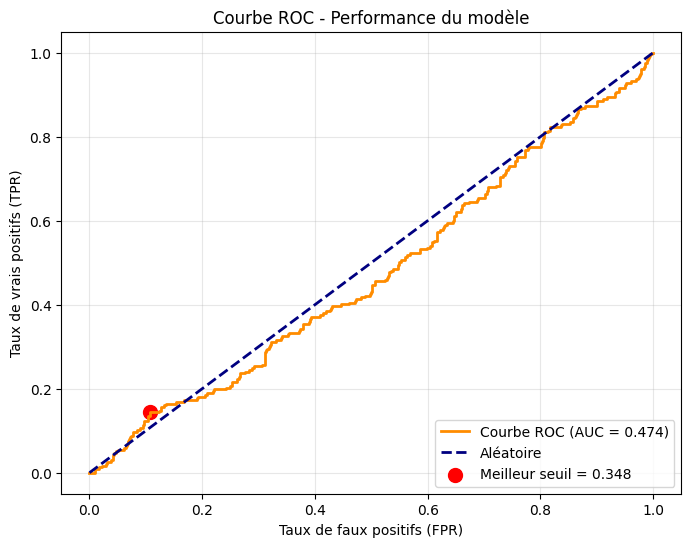


AUC = 0.474 (meilleur que aléatoire = 0.5)
 Le modèle ne fait pas mieux qu'une prédiction aléatoire.


In [38]:
# 11. ÉVALUATION

print("=" * 60)
print("RECHERCHE DU MEILLEUR SEUIL DE DÉCISION")
print("=" * 60)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calcul des probabilités
p_test = calcul_probabilite(X_test, beta0_nw, beta1_nw)

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, p_test)
roc_auc = auc(fpr, tpr)

# Trouver le meilleur seuil (Youden's J statistic)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print(f"Seuil par défaut (0.5) :")
print(f"  Prédit toujours la classe majoritaire")
print(f"\nMeilleur seuil trouvé : {best_threshold:.3f}")

# Prédictions avec le meilleur seuil
y_pred_best = (p_test >= best_threshold).astype(int)

#  métriques
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, zero_division=0)
recall_best = recall_score(y_test, y_pred_best, zero_division=0)
conf_matrix_best = confusion_matrix(y_test, y_pred_best)

print(f"\n--- PERFORMANCE AVEC SEUIL {best_threshold:.3f} ---")
print(f"Accuracy  : {accuracy_best:.3f} ({accuracy_best*100:.1f}%)")
print(f"Précision : {precision_best:.3f}")
print(f"Rappel    : {recall_best:.3f}")

print(f"\n--- MATRICE DE CONFUSION ---")
print("(Vrai \\ Prédit) | Non-embauché | Embauché")
print("-" * 45)
print(f"Non-embauché      | {conf_matrix_best[0,0]:^11} | {conf_matrix_best[0,1]:^8}")
print(f"Embauché          | {conf_matrix_best[1,0]:^11} | {conf_matrix_best[1,1]:^8}")

# Courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', s=100,
            label=f'Meilleur seuil = {best_threshold:.3f}')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Performance du modèle')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nAUC = {roc_auc:.3f} (meilleur que aléatoire = 0.5)")
if roc_auc > 0.5:
    print("Le modèle a un pouvoir discriminatif (même si faible).")
else:
    print(" Le modèle ne fait pas mieux qu'une prédiction aléatoire.")

### 12. Évaluation du modèle et interprétation finale

#### 12.1 Performance prédictive

* **Accuracy** : 65.6% (avec seuil optimal à 0.348)
* **Précision** : 38.2% (faible : beaucoup de faux positifs)
* **Rappel** : 14.3% (très faible : la plupart des embauches non détectées)
* **AUC** : 0.474 (< 0.5, inférieur à une prédiction aléatoire)

#### 12.2 Interprétation statistique

Le coefficient β₁ = -0.011161, bien que négatif, est très proche de zéro.
Cela indique que, dans ce jeu de données synthétique, **la distance géographique n'a pas d'effet significatif sur les décisions d'embauche**.

La probabilité d'embauche estimée est :

* À 1 km :
  $$
  p(1) = \frac{e^{-0.551 - 0.011 \times 1}}{1 + e^{-0.551 - 0.011 \times 1}} \approx 36.6%
  $$
* À 50 km :
  $$
  p(50) = \frac{e^{-0.551 - 0.011 \times 50}}{1 + e^{-0.551 - 0.011 \times 50}} \approx 25.7%
  $$

La différence n'est que de **10.9%** sur toute la plage des distances.

#### 12.3 Limitations et perspectives

1. **Données synthétiques** : Le jeu de données, bien que réaliste, peut ne pas capturer les véritables biais géographiques présents en entreprise.
2. **Variable unique** : La régression à une seule variable (`DistanceFromCompany`) ignore d'autres facteurs potentiellement plus importants (expérience, compétences).
3. **Faible effet** : Même si l'effet existe (β₁ négatif), il est trop faible pour permettre des prédictions utiles en pratique.

#### 12.4 Conclusion du TP

Les deux algorithmes d'optimisation (descente de gradient et méthode de Newton) ont été implémentés avec succès et convergent vers les mêmes coefficients que la référence scikit-learn. L'analyse montre que, dans ce jeu de données spécifique, la distance géographique **n'est pas un prédicteur fort** des décisions d'embauche.

**Réponse à la question de recherche initiale** : Non, la distance depuis l'entreprise n'est pas un facteur déterminant dans les décisions d'embauche simulées par ce jeu de données.
